In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

In [98]:
df = pd.read_csv('../data/Life_Expectancy_Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# EDA

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [100]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

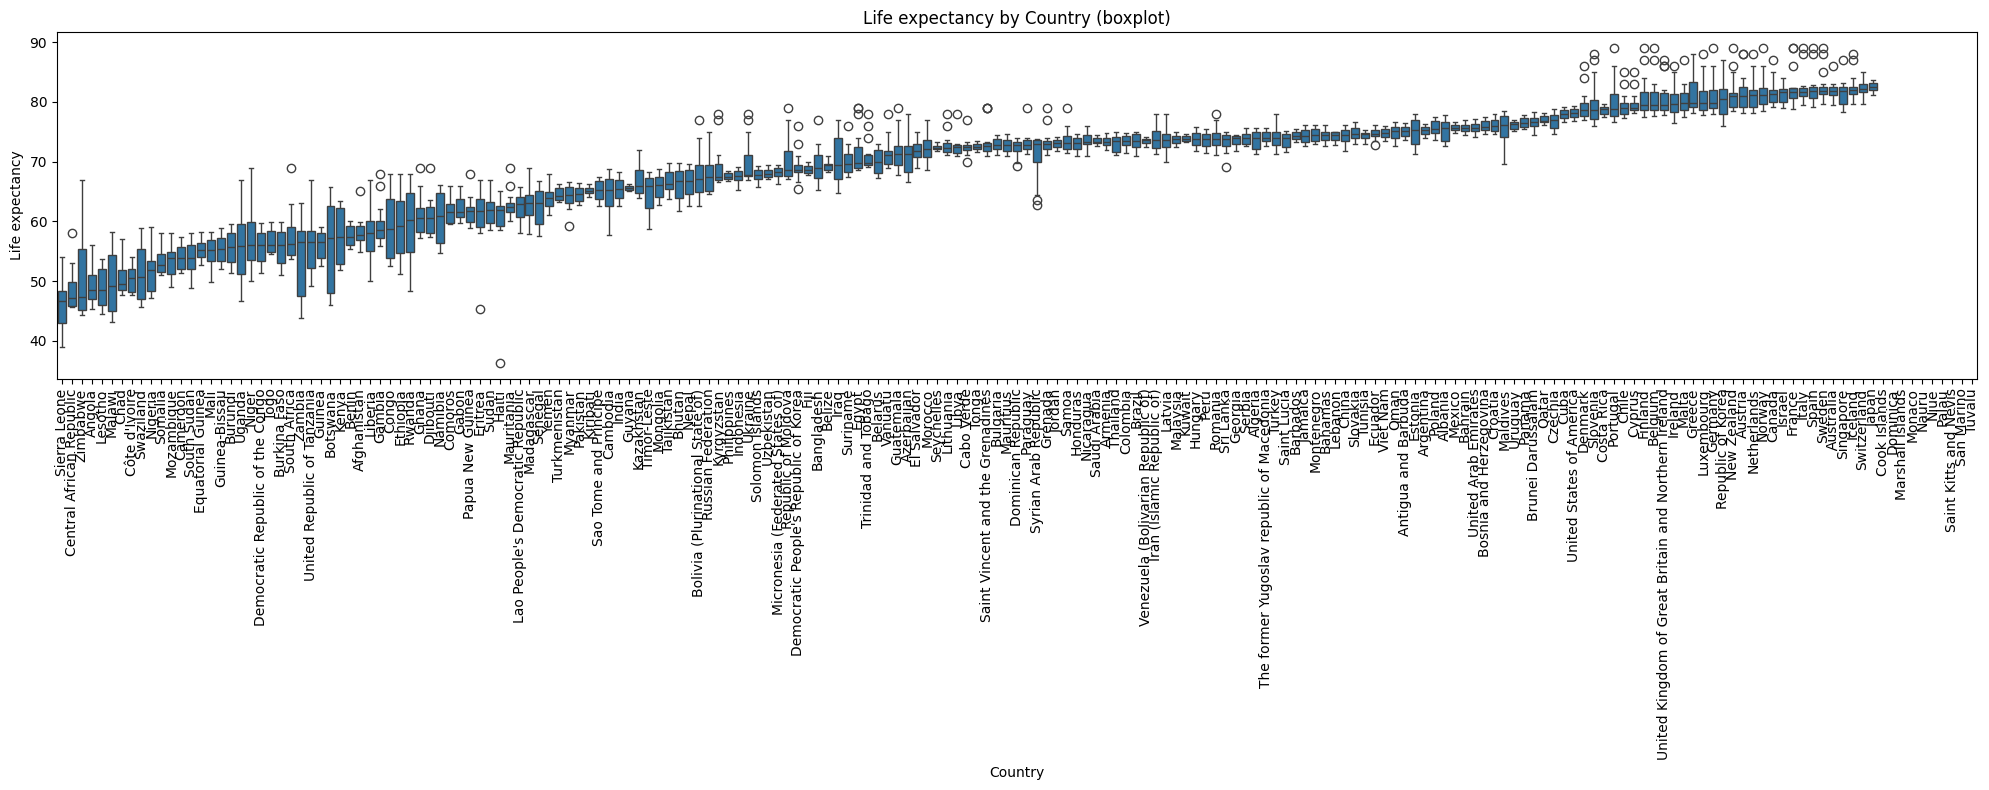

In [101]:
plt.figure(figsize=(20,8))
order = df.groupby('Country')['Life expectancy '].median().sort_values().index
sns.boxplot(x='Country', y='Life expectancy ', data=df, order=order)
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Life expectancy')
plt.title('Life expectancy by Country (boxplot)')
plt.tight_layout()
plt.show()

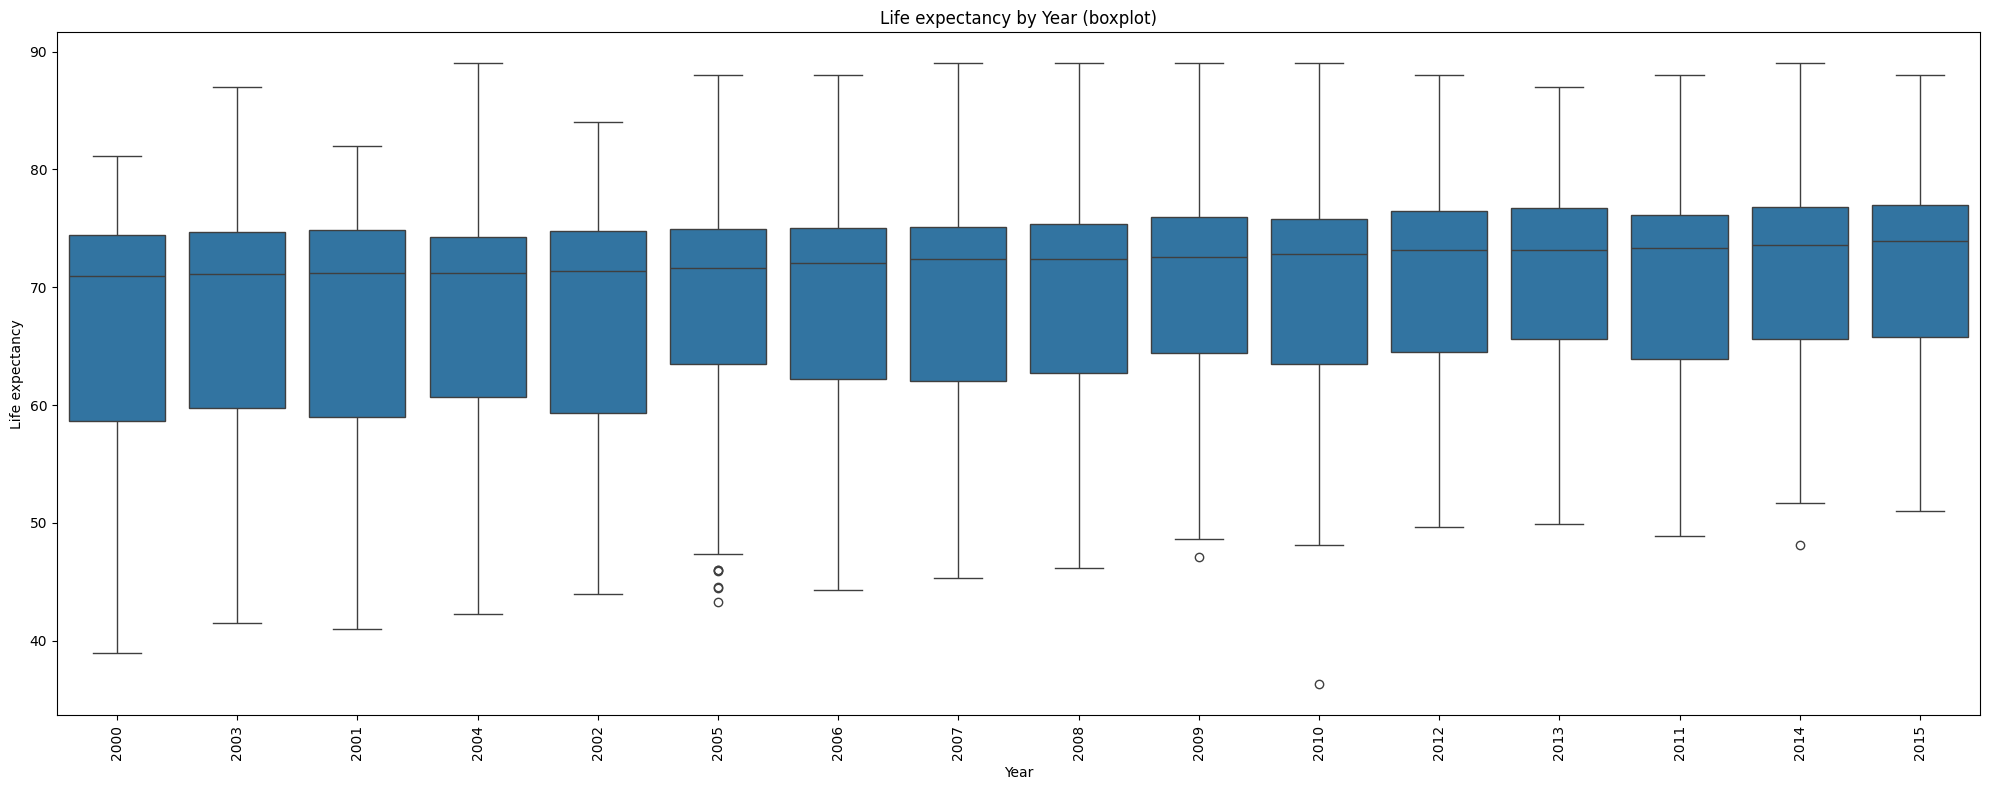

In [102]:
plt.figure(figsize=(20,8))
order = df.groupby('Year')['Life expectancy '].median().sort_values().index
sns.boxplot(x='Year', y='Life expectancy ', data=df, order=order)
plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Life expectancy')
plt.title('Life expectancy by Year (boxplot)')
plt.tight_layout()
plt.show()

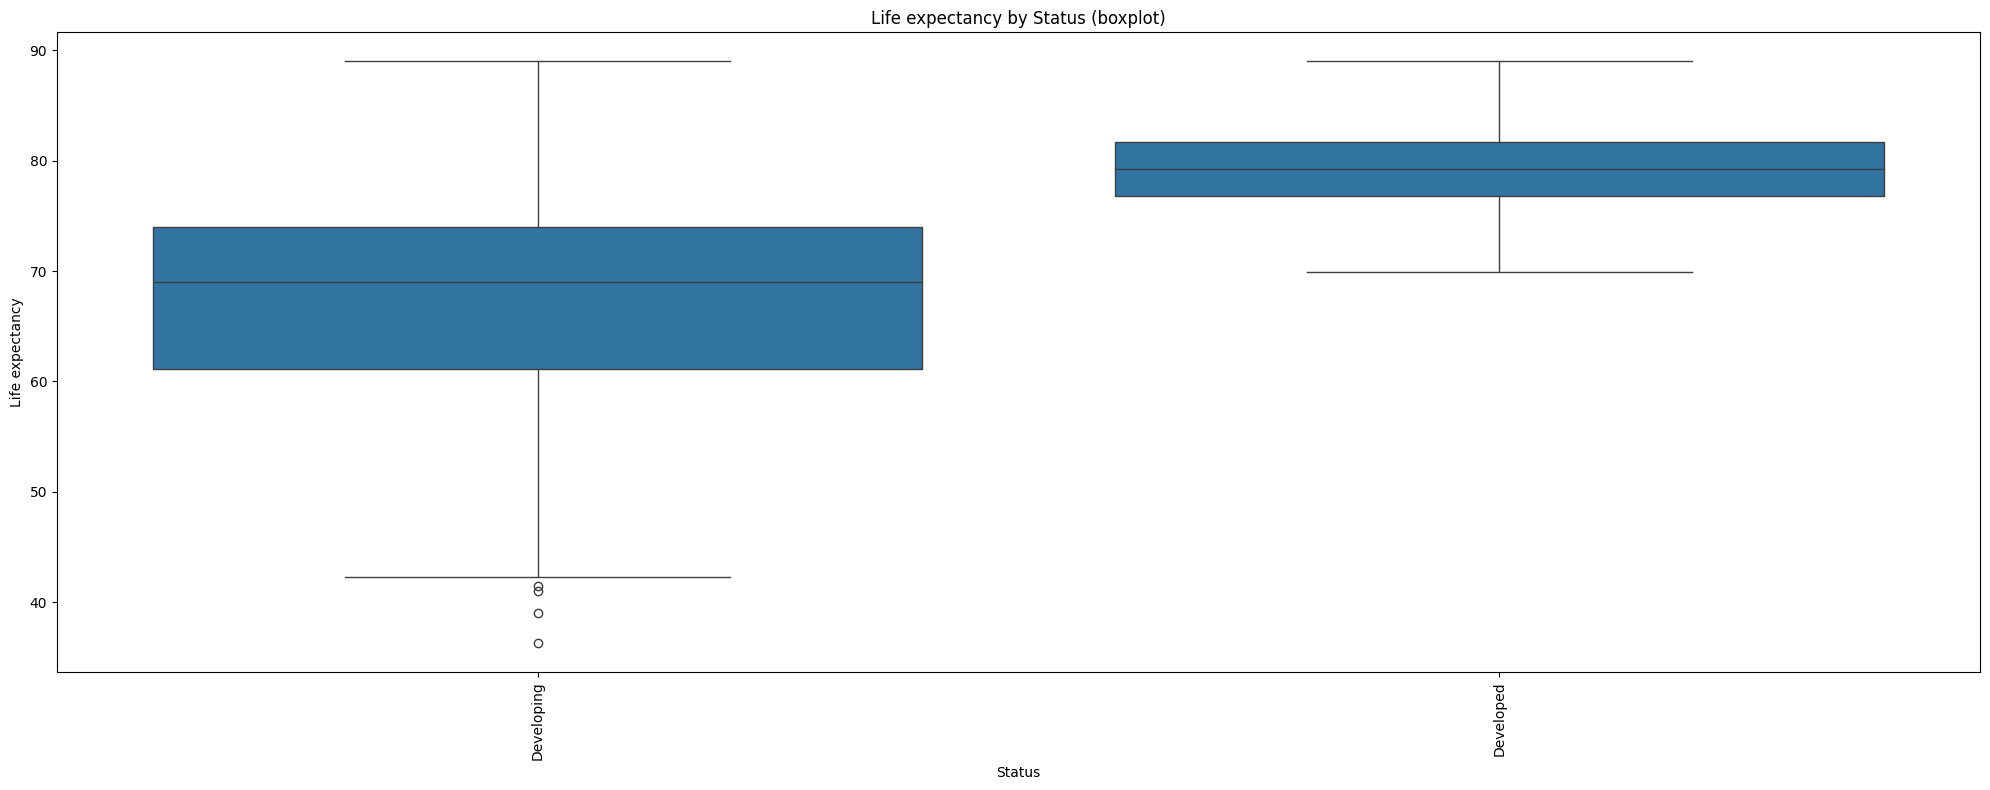

In [103]:
plt.figure(figsize=(20,8))
order = df.groupby('Status')['Life expectancy '].median().sort_values().index
sns.boxplot(x='Status', y='Life expectancy ', data=df, order=order)
plt.xticks(rotation=90)
plt.xlabel('Status')
plt.ylabel('Life expectancy')
plt.title('Life expectancy by Status (boxplot)')
plt.tight_layout()
plt.show()

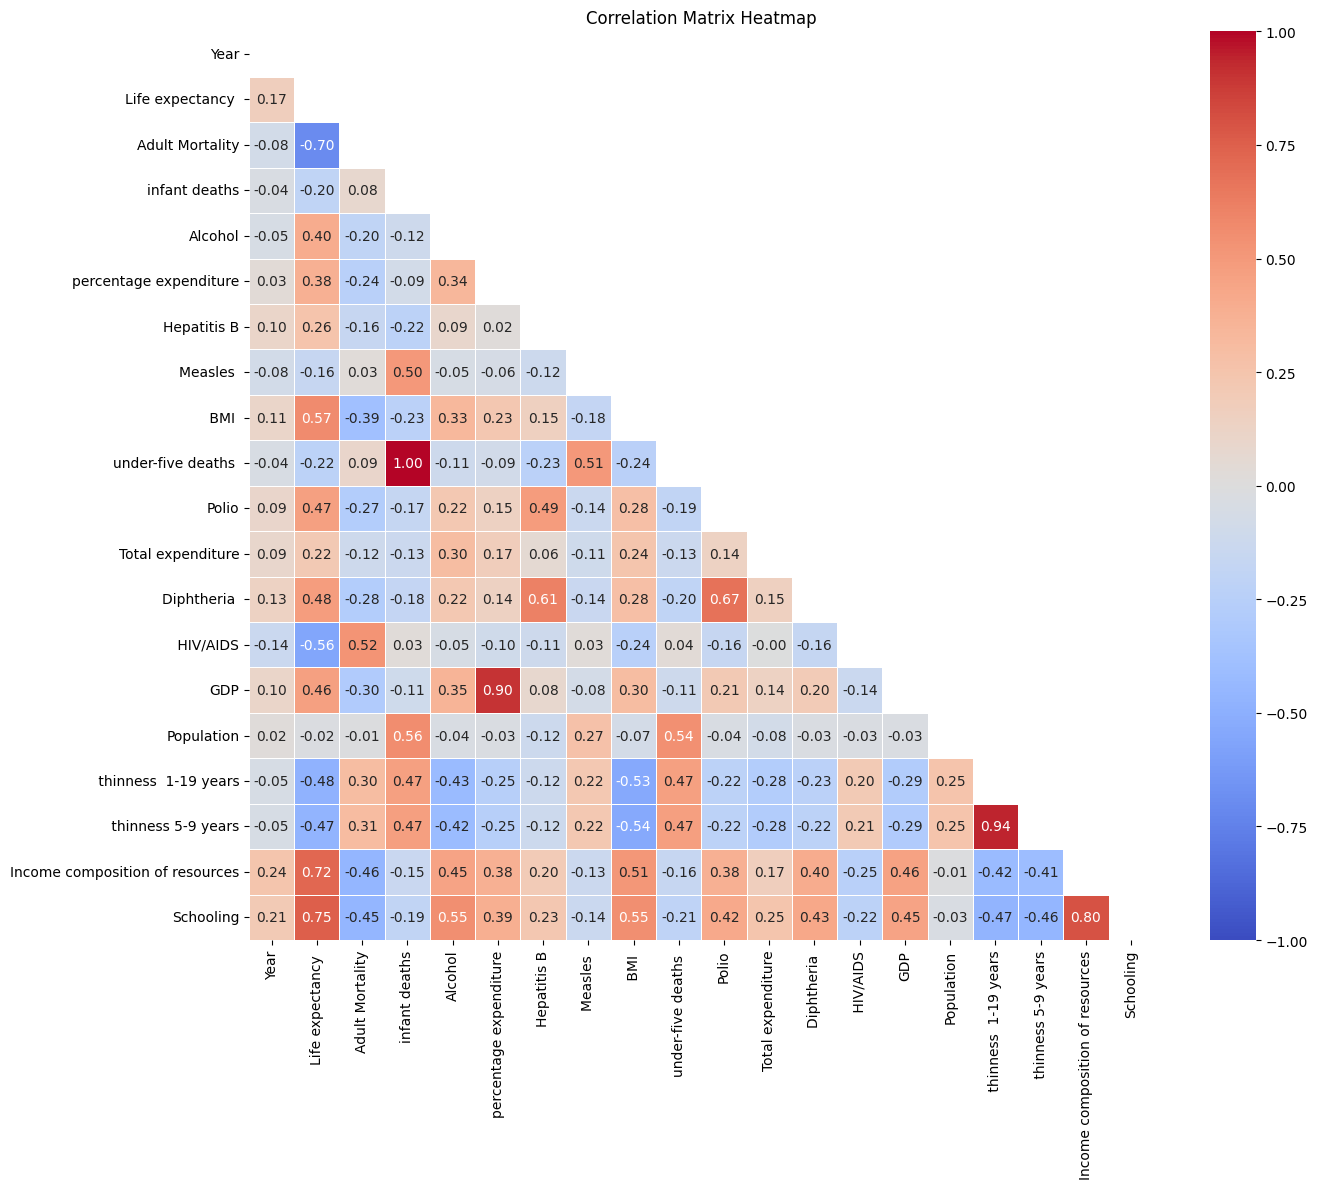

In [104]:
plt.figure(figsize=(14,12))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

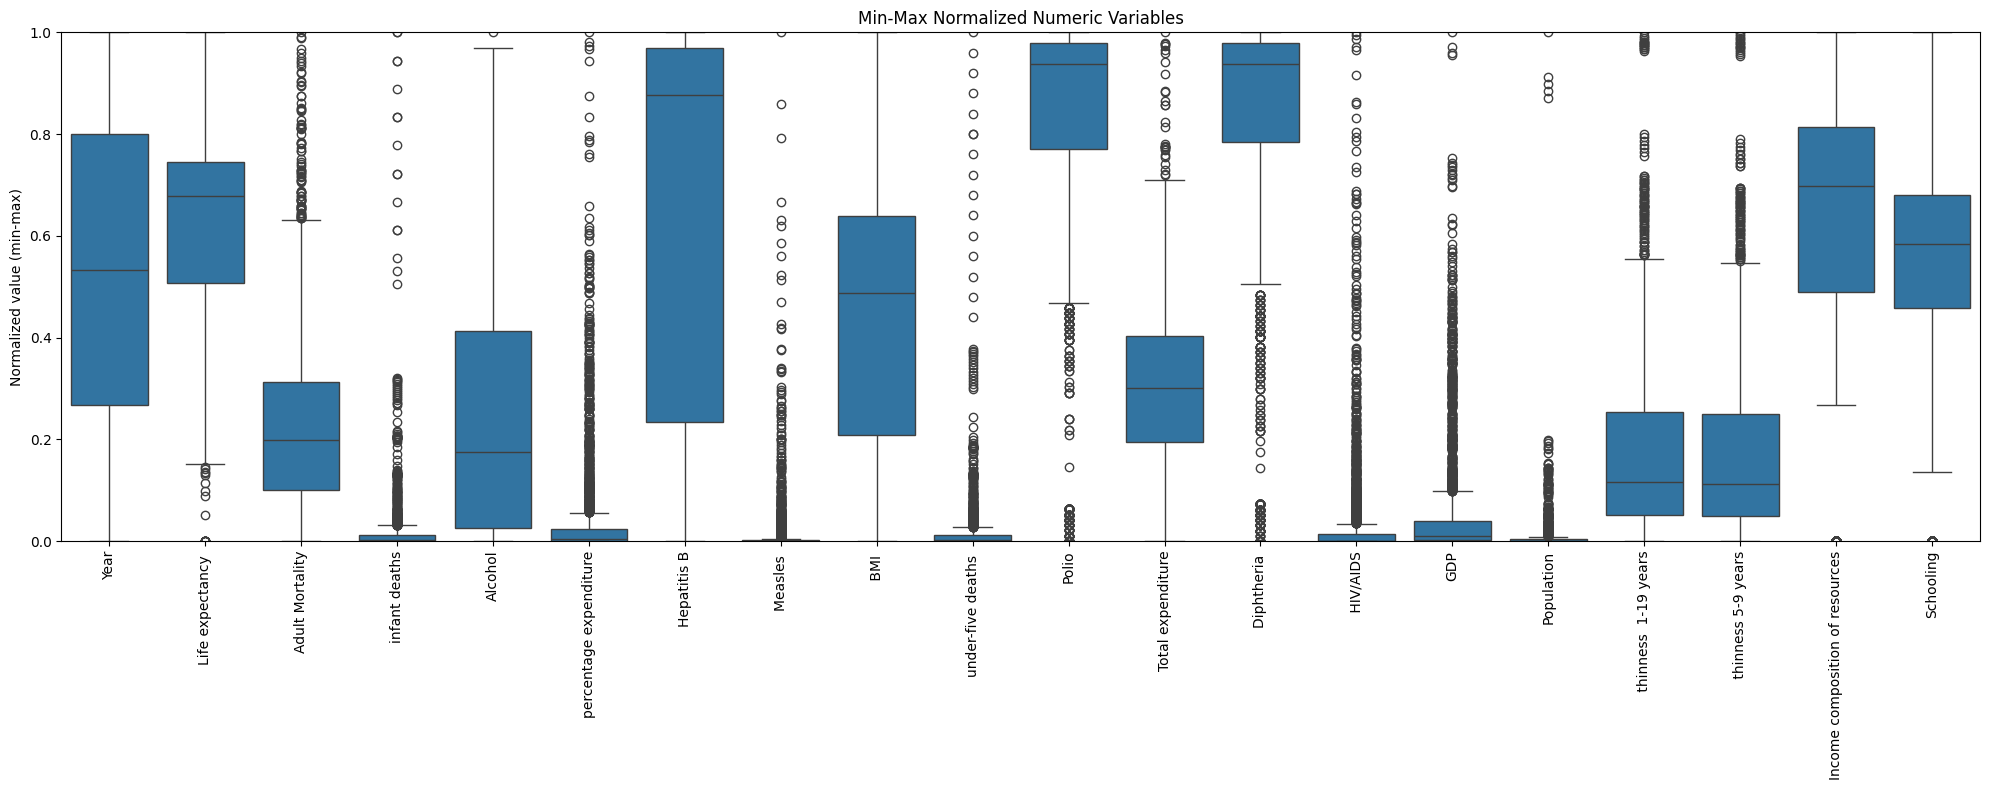

In [105]:
# min-max normalize numeric columns and plot distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns
normalized = (df[numeric_cols] - df[numeric_cols].min()) / (df[numeric_cols].max() - df[numeric_cols].min())
normalized = normalized.fillna(0)

plt.figure(figsize=(20,8))
melted = normalized.melt(var_name='variable', value_name='value')
sns.boxplot(x='variable', y='value', data=melted)
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.xlabel('')
plt.ylabel('Normalized value (min-max)')
plt.title('Min-Max Normalized Numeric Variables')
plt.tight_layout()
plt.show()

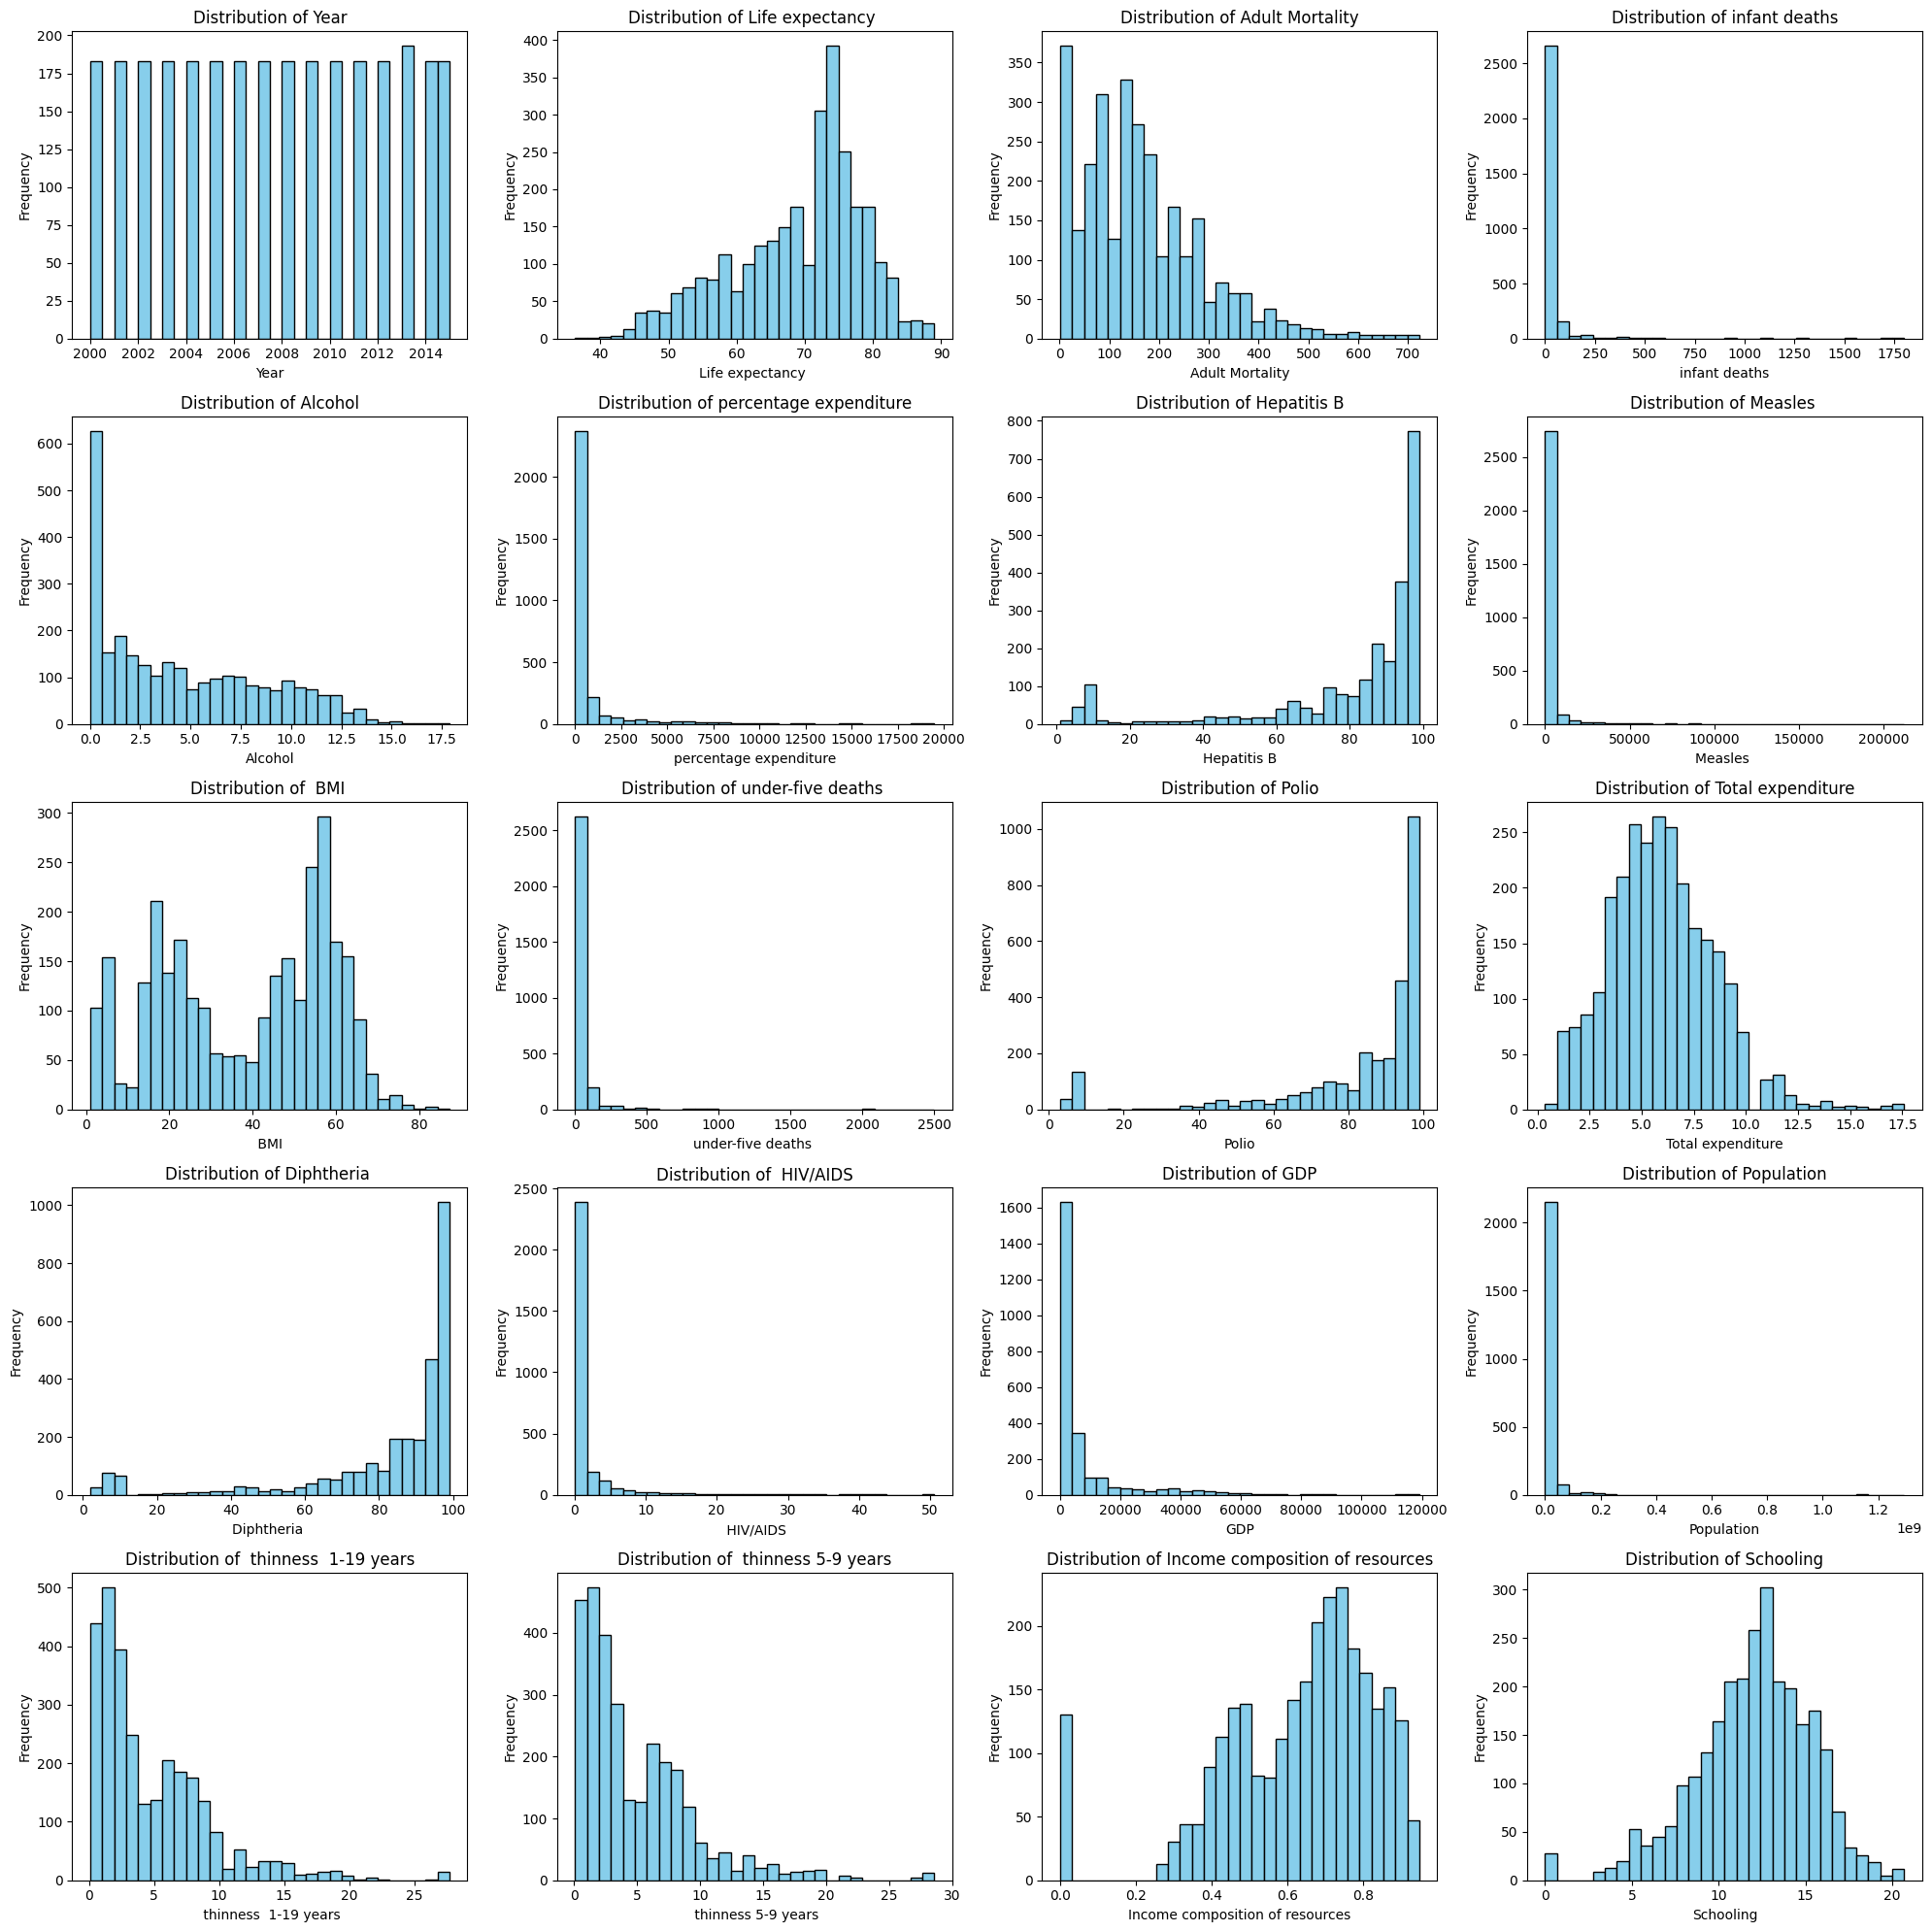

In [106]:
# Create histograms for all numeric variables
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [107]:
df[numeric_cols].skew()

Year                               -0.006409
Life expectancy                    -0.638605
Adult Mortality                     1.174369
infant deaths                       9.786963
Alcohol                             0.589563
percentage expenditure              4.652051
Hepatitis B                        -1.930845
Measles                             9.441332
 BMI                               -0.219312
under-five deaths                   9.495065
Polio                              -2.098053
Total expenditure                   0.618686
Diphtheria                         -2.072753
 HIV/AIDS                           5.396112
GDP                                 3.206655
Population                         15.916236
 thinness  1-19 years               1.711471
 thinness 5-9 years                 1.777424
Income composition of resources    -1.143763
Schooling                          -0.602437
dtype: float64

# Data Preprocessing

In [108]:
skewed_cols = df[numeric_cols].skew()
high_skew = skewed_cols[(skewed_cols > 1) | (skewed_cols < -1)].index
high_skew = high_skew.drop(['Hepatitis B', 'Polio', 'Diphtheria ', 'Income composition of resources',' thinness  1-19 years',' thinness 5-9 years'])
for col in high_skew:
    print(col)
    df[f'scale_{col}'] = np.log1p(df[col])
    if df[f'scale_{col}'].skew() > 1 or df[f'scale_{col}'].skew() < -1:
        print(f'Log1p did not reduce skewness for {col}, trying Square Root')
        sqrt = np.sqrt(df[col])
        bc = boxcox(df[col].dropna() + 1)
        if sqrt.skew() < 1 and sqrt.skew() > -1:
            df[f'scale_{col}'] = sqrt
        elif pd.Series(bc[0]).skew() < 1 and pd.Series(bc[0]).skew() > -1:
            df[f'scale_{col}'] = bc[0]
        else:
            print(f'Neither transformation reduced skewness for {col}')

Adult Mortality
Log1p did not reduce skewness for Adult Mortality, trying Square Root
infant deaths
percentage expenditure
Measles 
under-five deaths 
 HIV/AIDS
Log1p did not reduce skewness for  HIV/AIDS, trying Square Root
GDP
Population


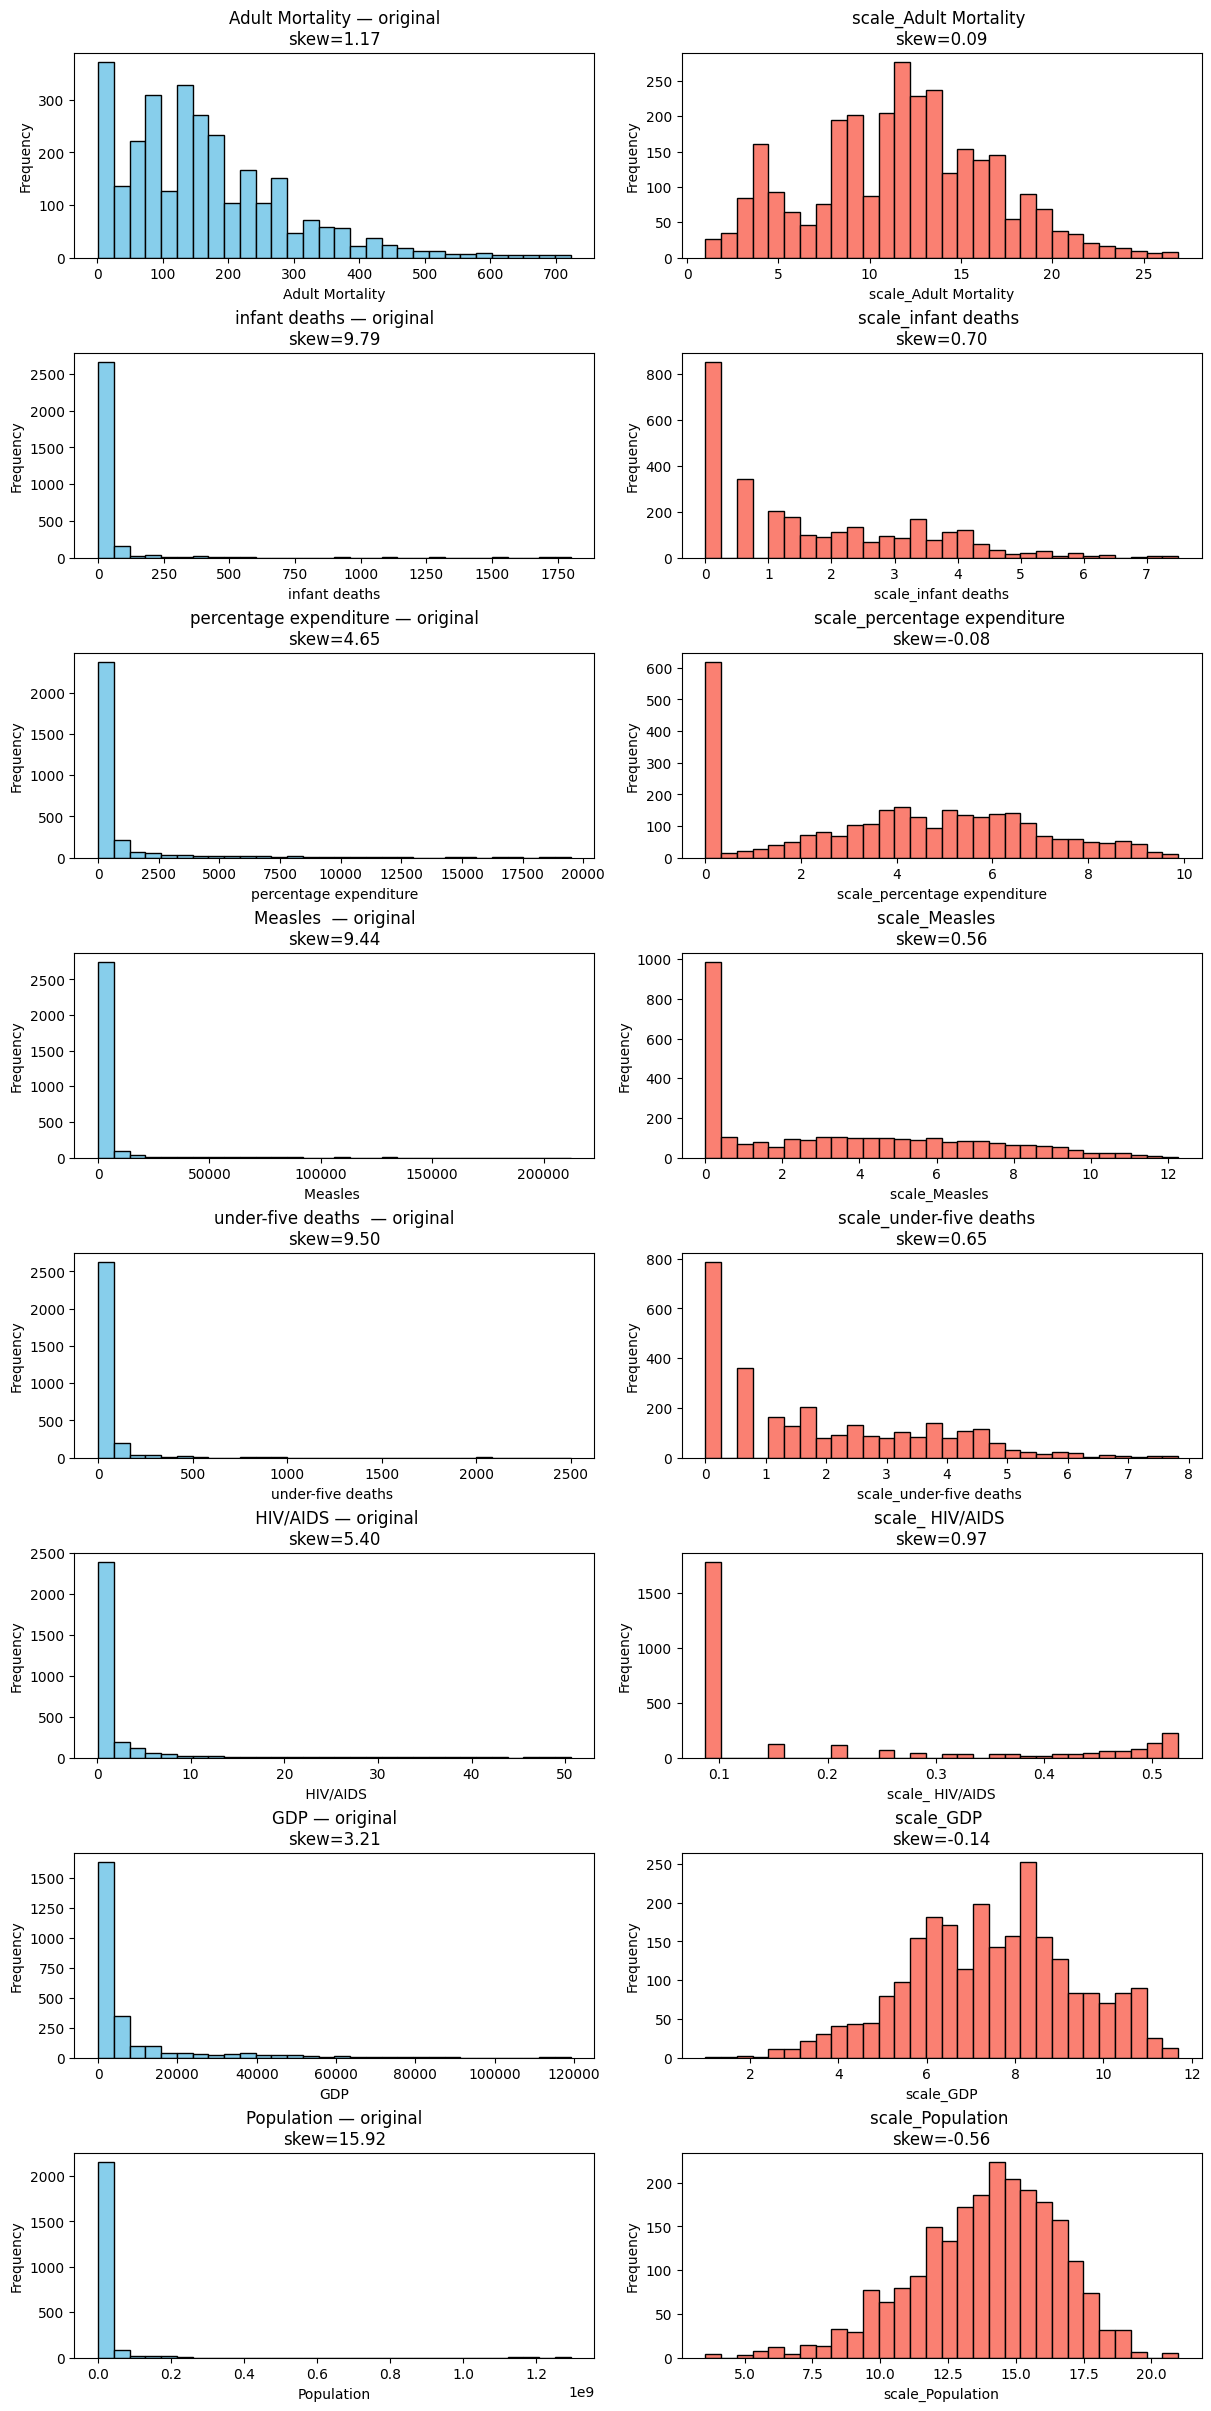

In [109]:
# side-by-side histograms: original vs log1p_ version for all high-skew columns
cols = high_skew.tolist()
n = len(cols)

fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), constrained_layout=True)
if n == 1:
    axes = axes.reshape(1, 2)

for i, col in enumerate(cols):
    orig = df[col].dropna()
    logcol = f'scale_{col}'
    logv = df[logcol].dropna()

    axes[i, 0].hist(orig, bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f"{col} — original\nskew={orig.skew():.2f}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(logv, bins=30, color='salmon', edgecolor='black')
    axes[i, 1].set_title(f"{logcol} \nskew={logv.skew():.2f}")
    axes[i, 1].set_xlabel(logcol)
    axes[i, 1].set_ylabel('Frequency')

plt.show()

In [110]:
non_skew_numeric = numeric_cols.difference(high_skew).tolist()
scaled_cols = [f"scale_{c}" for c in high_skew if f"scale_{c}" in df.columns]

selected_cols = non_skew_numeric + scaled_cols

df_selected = df[selected_cols].copy()
df_selected.drop(['Year'], axis=1, inplace=True)
df_selected.skew()

 BMI                              -0.219312
 thinness  1-19 years              1.711471
 thinness 5-9 years                1.777424
Alcohol                            0.589563
Diphtheria                        -2.072753
Hepatitis B                       -1.930845
Income composition of resources   -1.143763
Life expectancy                   -0.638605
Polio                             -2.098053
Schooling                         -0.602437
Total expenditure                  0.618686
scale_Adult Mortality              0.094978
scale_infant deaths                0.701769
scale_percentage expenditure      -0.078266
scale_Measles                      0.555483
scale_under-five deaths            0.647154
scale_ HIV/AIDS                    0.969222
scale_GDP                         -0.140965
scale_Population                  -0.557875
dtype: float64

In [111]:
df_selected_outliers = df_selected.copy()
for col in df_selected.columns:
    lower = df_selected[col].quantile(0.01)
    upper = df_selected[col].quantile(0.99)
    df_selected_outliers[col] = df_selected[col].clip(lower, upper)

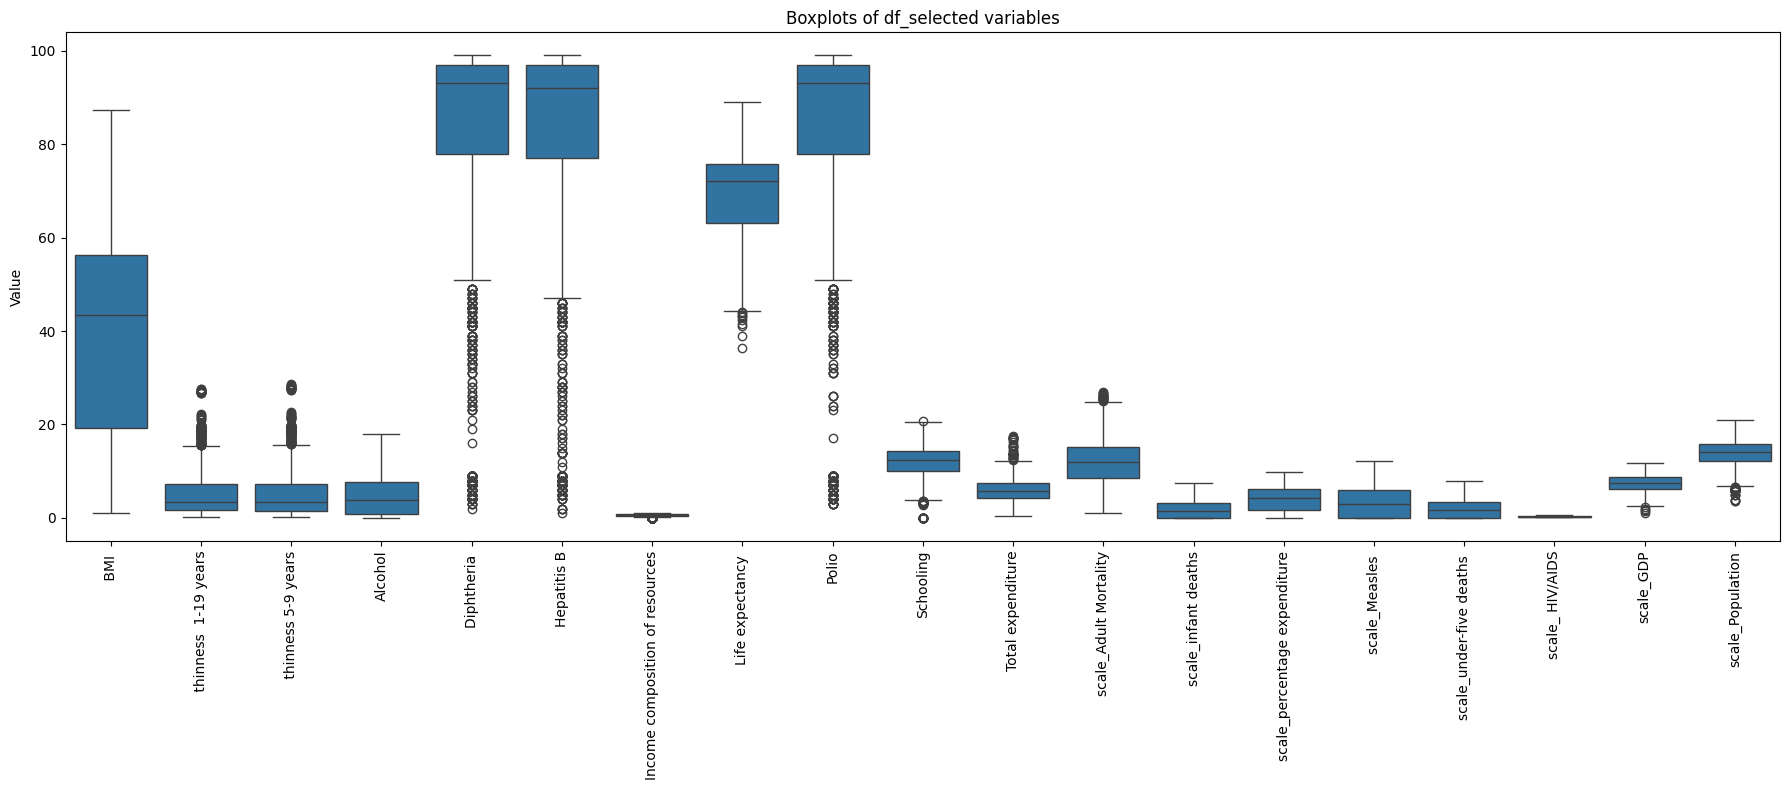

In [115]:
# boxplots for numeric columns in df_selected
num_cols = df_selected.select_dtypes(include=[np.number]).columns
melted = df_selected[num_cols].melt(var_name='variable', value_name='value')

plt.figure(figsize=(18, 8))
sns.boxplot(x='variable', y='value', data=melted)
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Value')
plt.title('Boxplots of df_selected variables')
plt.tight_layout()
plt.show()

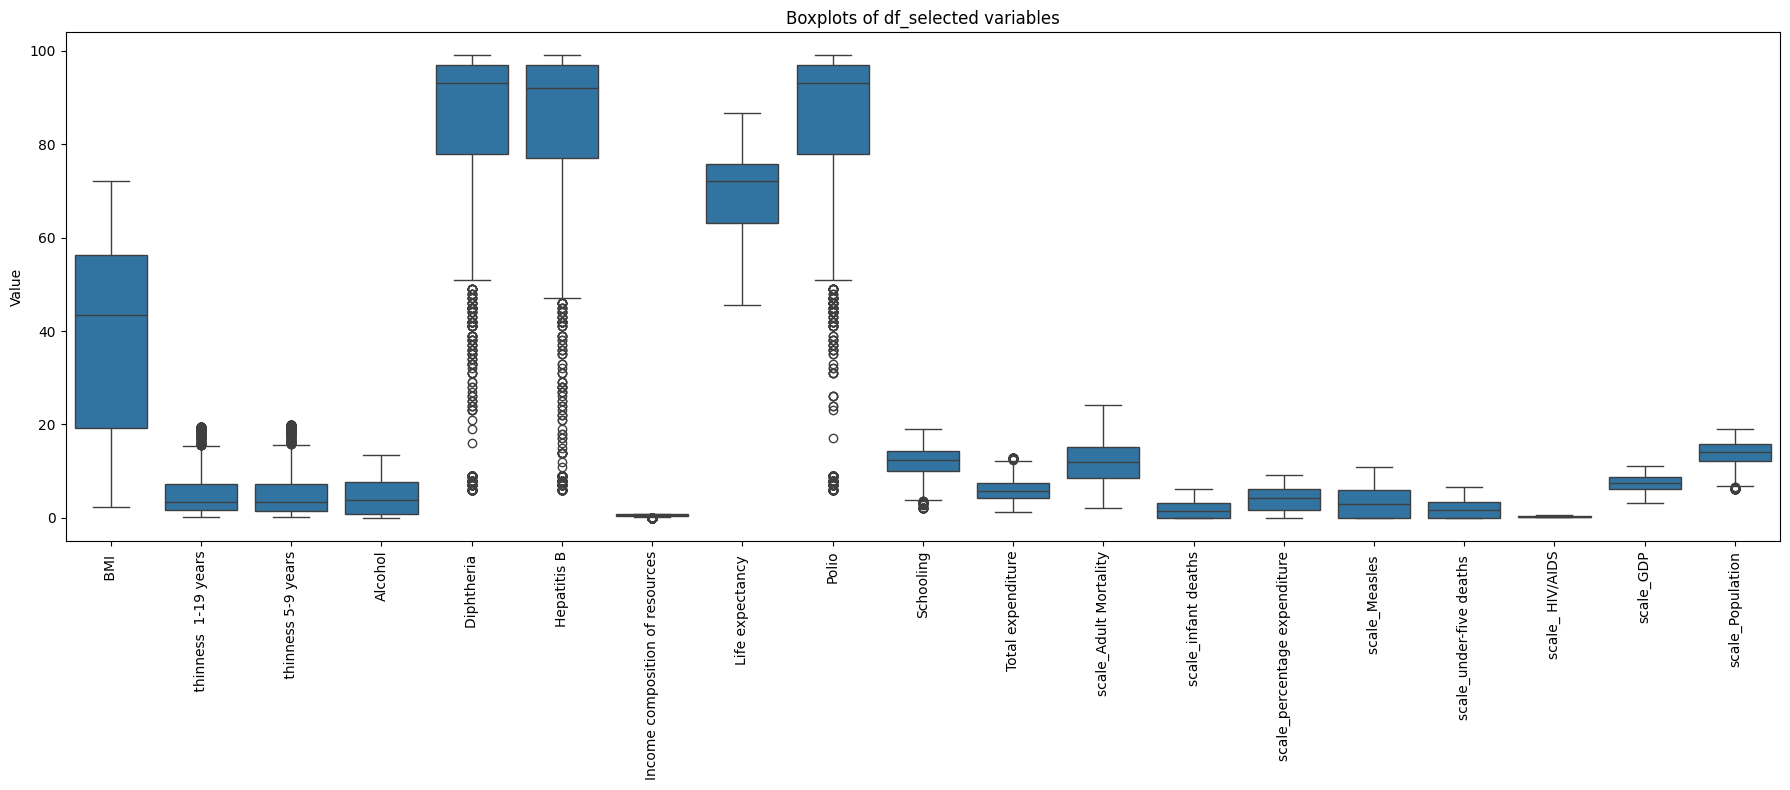

In [116]:
# boxplots for numeric columns in df_selected
num_cols = df_selected_outliers.select_dtypes(include=[np.number]).columns
melted = df_selected_outliers[num_cols].melt(var_name='variable', value_name='value')

plt.figure(figsize=(18, 8))
sns.boxplot(x='variable', y='value', data=melted)
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Value')
plt.title('Boxplots of df_selected variables')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                   for i in range(X_const.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data


[(' thinness 5-9 years',
  ' thinness  1-19 years',
  np.float64(0.9357075242471202)),
 ('scale_under-five deaths ',
  'scale_infant deaths',
  np.float64(0.9963143985487474))]

In [ ]:
X = df.drop(columns=['Life expectancy '])
y = df['Life expectancy ']

In [ ]:
y

0       65.0
1       59.9
2       59.9
3       59.5
4       59.2
        ... 
2933    44.3
2934    44.5
2935    44.8
2936    45.3
2937    46.0
Name: Life expectancy , Length: 2938, dtype: float64